<a href="https://colab.research.google.com/github/erandimalk-glitch/st20316719-CST7000-S2-25/blob/main/Product_Classification_Atlas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Product Classification on the Atlas Fashion Dataset

> **A Comparative Study of Machine Learning and Deep Learning Models
> for Product Classification Using the Atlas Fashion Dataset.**
>
> This notebook is the full implementation that supports the MSc
> dissertation of the same title. It builds the dataset, trains all
> nine classifiers, and produces the exact numbers reported in
> Chapter 4 of the dissertation.

## What this notebook does

1. **Load the dataset.** Reads `atlas_dataset.json` (183,996 fashion
   items) and flattens it into a tidy DataFrame.
2. **Clean the data.** Drops rows with empty titles / categories and
   applies an optional image-quality filter using `zvsn_data.json` to
   remove zoomed images.
3. **Synthesise balanced pairs.** Atlas is a single-product catalogue,
   so 25,000 positive pairs (same `gender / wear / category`) and
   25,000 negative pairs (different categories, inverse-frequency
   weighted) are generated to frame the problem as a binary
   classification task.
4. **Engineer features.** Builds TF-IDF features (up to 20,000
   1-grams + 2-grams, sublinear TF) on the left and right titles, and
   label-encodes the `gender`, `wear`, and `category` tags.
5. **Split the data.** Stratified 64 / 16 / 20 split into
   train / validation / test (32,000 / 8,000 / 10,000 pairs).
6. **Train and evaluate nine classifiers** on the same features and
   the same test set: Random Forest, K-Nearest Neighbours, Linear SVM,
   Multinomial Naive Bayes, Decision Tree, XGBoost, Feed-forward
   Neural Network, Siamese Neural Network, and LSTM.
7. **Report results.** Produces per-model classification reports,
   confusion matrices, a final comparison table, and an accuracy bar
   chart - the same artefacts used as Figures 4.1 - 4.3 of the
   dissertation.

## Setup

Mount Drive, install missing packages, and `cd` into the project folder.

In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    print('Not running in Colab - skipping Drive mount.')

Not running in Colab - skipping Drive mount.


In [ ]:
import importlib, sys
# Colab already ships numpy / pandas / sklearn / scipy / xgboost /
# tensorflow / keras / torch / torchvision / PIL / h5py.
# Locally (e.g. when Colab RAM isn't enough) we also install tensorflow
# so the NN / Siamese / LSTM cells can run. We skip the pip call when
# every package is already importable, which keeps the cell idempotent
# on a dedicated venv.
_required = ['xgboost', 'sklearn', 'imblearn']
if not IN_COLAB:
    _required += ['tensorflow']
_missing = [p for p in _required if importlib.util.find_spec(p) is None]
if _missing:
    if IN_COLAB:
        !pip install -q --upgrade xgboost scikit-learn imbalanced-learn
    else:
        !{sys.executable} -m pip install -q --upgrade xgboost scikit-learn imbalanced-learn tensorflow
else:
    print('All required packages already installed - skipping pip.')

ERROR: Could not find a version that satisfies the requirement tensorflow (from versions: none)

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for tensorflow


In [ ]:
# Adjust this path to wherever you uploaded `atlas_assets/` and this notebook.
import os
PROJECT_DIR = '/content/drive/MyDrive/Research' if IN_COLAB else '.'
os.chdir(PROJECT_DIR)
print('Working dir:', os.getcwd())
print('Contents:  ', sorted(os.listdir('.')))

Working dir: C:\Research
Contents:   ['.venv-tf', '__pycache__', 'atlas_assets', 'product_matching_atlas.ipynb', 'product_matching_atlas.py', 'product_matching_project.py', 'requirements.txt', 'results_atlas.csv']


## Imports

In [ ]:
import json, random, re, sys, time, warnings
from dataclasses import dataclass, field
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.sparse import csr_matrix, hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score,
                             recall_score, f1_score)
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

# Soft imports for the deep-learning heads
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    HAS_TF = True
    print('TensorFlow', tf.__version__)
except ImportError:
    HAS_TF = False
    print('TensorFlow not available - NN/Siamese/LSTM cells will be skipped.')

try:
    import torch, torchvision
    from PIL import Image
    HAS_TORCH = True
    print('PyTorch', torch.__version__)
except ImportError:
    HAS_TORCH = False
    print('PyTorch not available - caption fallback disabled.')

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

TensorFlow 2.21.0


PyTorch 2.11.0+cpu


## Configuration

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
if HAS_TF: tf.random.set_seed(SEED)
if HAS_TORCH: torch.manual_seed(SEED)

ATLAS_DIR          = Path('atlas_assets')
ATLAS_DATASET_JSON = ATLAS_DIR / 'atlas_dataset.json'
ZVSN_DATA_JSON     = ATLAS_DIR / 'zvsn_data.json'

CONFIG = dict(
    n_positive_pairs      = 25_000,
    n_negative_pairs      = 25_000,
    tfidf_max_features    = 20_000,
    test_size             = 0.2,
    val_size              = 0.2,
    use_zvsn_label_filter = True,
)
CONFIG

{'n_positive_pairs': 25000,
 'n_negative_pairs': 25000,
 'tfidf_max_features': 20000,
 'test_size': 0.2,
 'val_size': 0.2,
 'use_zvsn_label_filter': True}

## Data Loading

Reads `atlas_dataset.json` and flattens it into a tidy DataFrame.
Each row gets `gender / wear / category` from `sentences[0].tokens`.

In [ ]:
def load_atlas_dataset(json_path=ATLAS_DATASET_JSON) -> pd.DataFrame:
    with open(json_path, 'r', encoding='utf-8') as f:
        raw = json.load(f)
    images = raw['images'] if isinstance(raw, dict) else raw
    rows = []
    for it in images:
        toks = (it.get('sentences', [{}])[0].get('tokens', []) + ['', '', ''])[:3]
        rows.append(dict(
            filename  = os.path.basename(it.get('filename', '')),
            title     = it.get('title', '') or '',
            image_url = it.get('image_url', ''),
            split     = it.get('split', ''),
            gender    = toks[0],
            wear      = toks[1],
            category  = toks[2],
        ))
    df = pd.DataFrame(rows)
    return df[df['category'].astype(bool) & df['title'].astype(bool)].reset_index(drop=True)

atlas_df = load_atlas_dataset()
print(f'Loaded {len(atlas_df):,} rows')
print(f'Splits:     {atlas_df["split"].value_counts().to_dict()}')
print(f'Categories: {atlas_df["category"].nunique()} unique')
atlas_df.head()

Loaded 183,996 rows
Splits:     {'train': 117779, 'test': 55199, 'val': 11018}
Categories: 48 unique


,filename,title,image_url,split,gender,wear,category
0,euro-fashion-men-s-cotton-brief-pack-of-3-c9f8...,euro fashion\n men's cotton brief (pack of 3 ),https://images.voonik.com/01993582/euro-fashio...,train,Men,Inner Wear,Underwear
1,zander-mens-brief-sk-zander-brief-oe_g-melange...,zander mens brief(sk/zander brief oe_g.melange...,https://images.voonik.com/83937442/zander-mens...,train,Men,Inner Wear,Underwear
2,euro-fashion-men-s-cotton-brief-pack-of-4-d038...,euro fashion\n men's cotton brief (pack of 4 ),https://images.voonik.com/19324582/euro-fashio...,train,Men,Inner Wear,Underwear
3,euro-fashion-men-s-cotton-brief-pack-of-3-a095...,euro fashion\n men's cotton brief (pack of 3 ),https://images.voonik.com/57104582/euro-fashio...,train,Men,Inner Wear,Underwear
4,euro-fashion-men-s-cotton-brief-pack-of-3-5906...,euro fashion\n men's cotton brief (pack of 3 ),https://images.voonik.com/93673582/euro-fashio...,train,Men,Inner Wear,Underwear


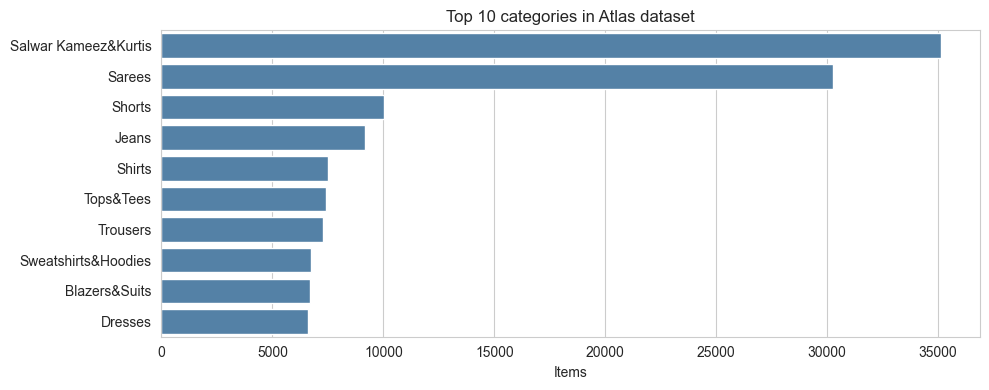

In [ ]:
top = atlas_df['category'].value_counts().head(10)
plt.figure(figsize=(10, 4))
sns.barplot(x=top.values, y=top.index, color='steelblue')
plt.title('Top 10 categories in Atlas dataset')
plt.xlabel('Items'); plt.ylabel('')
plt.tight_layout(); plt.show()

## Image-Quality Filter

Drop any rows whose `filename` is labelled `zoomed` in the bundled
`zvsn_data.json`. Cheap - no images required.

In [ ]:
def load_zvsn_labels(p=ZVSN_DATA_JSON):
    if not Path(p).exists(): return {}
    with open(p, 'r', encoding='utf-8') as f:
        items = json.load(f)
    return {os.path.basename(it['filename']): it['label']
            for it in items if it.get('filename')}

if CONFIG['use_zvsn_label_filter']:
    labels = load_zvsn_labels()
    before = len(atlas_df)
    atlas_df = atlas_df[atlas_df['filename']
                       .map(lambda fn: labels.get(fn, 'normal') != 'zoomed')] \
                   .reset_index(drop=True)
    print(f'Filtered zoomed images: {before:,} -> {len(atlas_df):,}')
else:
    print('Image-quality filter disabled.')

Filtered zoomed images: 183,996 -> 183,940


## Pair Synthesis

Atlas is **single-product** (no left/right pairs), so we manufacture them:

- **Positive (label=1)** - two distinct rows with the same 3-token category.
- **Negative (label=0)** - two rows from different categories, weighted by
  inverse frequency to avoid the long-tail Women/Ethnic majority dominating.

In [ ]:
def build_pairs(df, n_positive, n_negative, seed=42):
    rng = np.random.default_rng(seed)
    by_cat = df.groupby(['gender', 'wear', 'category']).indices
    cats_dup = [k for k, idx in by_cat.items() if len(idx) >= 2]
    weights = np.array([len(by_cat[k]) for k in cats_dup], dtype=float)
    weights /= weights.sum()

    pos_l, pos_r = [], []
    for c in rng.choice(len(cats_dup), size=n_positive, p=weights):
        i, j = rng.choice(by_cat[cats_dup[c]], size=2, replace=False)
        pos_l.append(i); pos_r.append(j)

    all_cats = list(by_cat.keys())
    neg_l, neg_r = [], []
    for _ in range(n_negative):
        a, b = rng.choice(len(all_cats), size=2, replace=False)
        neg_l.append(rng.choice(by_cat[all_cats[a]]))
        neg_r.append(rng.choice(by_cat[all_cats[b]]))

    L = df.iloc[np.r_[pos_l, neg_l]].reset_index(drop=True).add_suffix('_left')
    R = df.iloc[np.r_[pos_r, neg_r]].reset_index(drop=True).add_suffix('_right')
    out = pd.concat([L, R], axis=1)
    out['label'] = np.r_[np.ones(n_positive, int), np.zeros(n_negative, int)]
    return out.sample(frac=1, random_state=seed).reset_index(drop=True)

pairs = build_pairs(atlas_df,
                    n_positive=CONFIG['n_positive_pairs'],
                    n_negative=CONFIG['n_negative_pairs'],
                    seed=SEED)
print(f'Built {len(pairs):,} pairs '
      f'(pos={int((pairs["label"]==1).sum()):,}, '
      f'neg={int((pairs["label"]==0).sum()):,})')
pairs[['title_left','category_left','title_right','category_right','label']].head()

Built 50,000 pairs (pos=25,000, neg=25,000)


,title_left,category_left,title_right,category_right,label
0,Brown Cotton Readymade Kurta Pajama 138881,Kurta,Plain Cotton Slub Nehru Jacket in Navy Blue,Jackets,0
1,rg designers women's 3/4th sleeve designer cas...,Salwar Kameez&Kurtis,Gauhar Khan Pink Silk Long Anarkali Suit 94689,Salwar Kameez&Kurtis,1
2,Peter England Slim Fit Men's Black Trousers,Trousers,Indian Terrain Slim Fit Men's Dark Blue Trousers,Trousers,1
3,georgette/chiffon designer silk sarees,Sarees,Half and Half Printed Saree in Orange,Sarees,1
4,PeppermintGirls Navy Blue & White Dungarees wi...,Dungarees,Christy World Solid Men's Light Blue Track Pants,Tracks&Joggers,0


## Feature Engineering

- **TF-IDF** (1-2 grams, sublinear TF, top 20k features) on left + right titles.
- **LabelEncode** the `gender / wear / category` triples consistently
  across both sides.
- Concatenate everything into one sparse matrix.

In [ ]:
PUNCT = re.compile(r'[^\w\s]')
def normalise(s): return PUNCT.sub(' ', s.lower()).strip()

pairs['title_left']  = pairs['title_left'].fillna('').map(normalise)
pairs['title_right'] = pairs['title_right'].fillna('').map(normalise)

vec = TfidfVectorizer(max_features=CONFIG['tfidf_max_features'],
                      ngram_range=(1, 2), sublinear_tf=True)
vec.fit(pd.concat([pairs['title_left'], pairs['title_right']]))
tfidf_l = vec.transform(pairs['title_left'])
tfidf_r = vec.transform(pairs['title_right'])

encoders, cat_arrays = {}, []
for col in ('gender', 'wear', 'category'):
    enc = LabelEncoder()
    enc.fit(pd.concat([pairs[f'{col}_left'].fillna('<unk>'),
                       pairs[f'{col}_right'].fillna('<unk>')]))
    encoders[col] = enc
    cat_arrays.append(enc.transform(pairs[f'{col}_left'].fillna('<unk>')).reshape(-1, 1))
    cat_arrays.append(enc.transform(pairs[f'{col}_right'].fillna('<unk>')).reshape(-1, 1))

cat_matrix = csr_matrix(np.hstack(cat_arrays).astype(float))
X = hstack([tfidf_l, tfidf_r, cat_matrix]).tocsr()
y = pairs['label'].to_numpy()
print(f'X: {X.shape}  nnz={X.nnz:,}   y: {y.shape}')

X: (50000, 40006)  nnz=1,447,548   y: (50000,)


## Splitting Data

In [ ]:
X_tv, X_test, y_tv, y_test, pairs_tv, pairs_test = train_test_split(
    X, y, pairs, test_size=CONFIG['test_size'],
    stratify=y, random_state=SEED)
X_train, X_val, y_train, y_val, pairs_train, pairs_val = train_test_split(
    X_tv, y_tv, pairs_tv, test_size=CONFIG['val_size'],
    stratify=y_tv, random_state=SEED)
print(f'train: {X_train.shape[0]:,}   '
      f'val: {X_val.shape[0]:,}   '
      f'test: {X_test.shape[0]:,}')

train: 32,000   val: 8,000   test: 10,000


## Evaluation helper

Each model below logs into the shared `results` list via this helper so
the final comparison cell can render everything in one table.

              precision    recall  f1-score   support

           0       0.50      1.00      0.67      5000
           1       0.00      0.00      0.00      5000

    accuracy                           0.50     10000
   macro avg       0.25      0.50      0.33     10000
weighted avg       0.25      0.50      0.33     10000



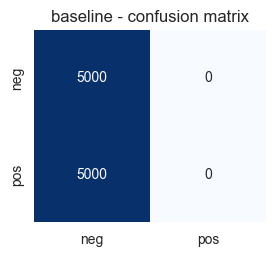

{'model': 'baseline',
 'accuracy': 0.5,
 'precision': 0.25,
 'recall': 0.5,
 'f1': 0.3333333333333333}

In [ ]:
results = []  # one dict per model
def evaluate(name, y_true, y_pred):
    print(classification_report(y_true, y_pred, zero_division=0))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(3, 2.5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['neg', 'pos'], yticklabels=['neg', 'pos'])
    plt.title(f'{name} - confusion matrix'); plt.show()
    metrics = dict(
        model     = name,
        accuracy  = accuracy_score(y_true, y_pred),
        precision = precision_score(y_true, y_pred, average='weighted', zero_division=0),
        recall    = recall_score(y_true, y_pred, average='weighted', zero_division=0),
        f1        = f1_score(y_true, y_pred, average='weighted', zero_division=0),
    )
    results.append(metrics)
    return metrics

# Trivial baseline so we always have a sanity floor in the comparison table.
_baseline = DummyClassifier(strategy='most_frequent').fit(X_train, y_train)
evaluate('baseline', y_test, _baseline.predict(X_test))

# Classification using Traditional Machine Learning

## Random Forest

              precision    recall  f1-score   support

           0       0.82      0.90      0.86      5000
           1       0.89      0.80      0.84      5000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



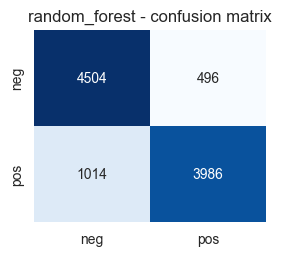

{'model': 'random_forest',
 'accuracy': 0.849,
 'precision': 0.8527864427788882,
 'recall': 0.849,
 'f1': 0.8485937406687121}

In [ ]:
clf = RandomForestClassifier(n_estimators=200, max_depth=20,
                             n_jobs=-1, random_state=SEED)
clf.fit(X_train, y_train)
evaluate('random_forest', y_test, clf.predict(X_test))

## K-Nearest Neighbours

              precision    recall  f1-score   support

           0       1.00      0.99      1.00      5000
           1       0.99      1.00      1.00      5000

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



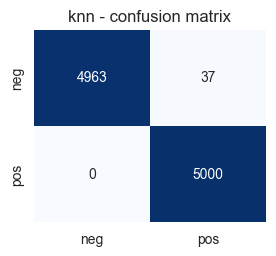

{'model': 'knn',
 'accuracy': 0.9963,
 'precision': 0.9963271788763152,
 'recall': 0.9963,
 'f1': 0.9962999493463067}

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn.fit(X_train, y_train)
evaluate('knn', y_test, knn.predict(X_test))

## Linear SVM

              precision    recall  f1-score   support

           0       0.79      0.76      0.77      5000
           1       0.77      0.80      0.78      5000

    accuracy                           0.78     10000
   macro avg       0.78      0.78      0.78     10000
weighted avg       0.78      0.78      0.78     10000



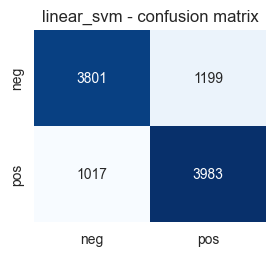

{'model': 'linear_svm',
 'accuracy': 0.7784,
 'precision': 0.7787693582489055,
 'recall': 0.7784,
 'f1': 0.7783265728940054}

In [ ]:
svm = LinearSVC(C=1.0, max_iter=5000, random_state=SEED)
svm.fit(X_train, y_train)
evaluate('linear_svm', y_test, svm.predict(X_test))

## Multinomial Naive Bayes

Works because TF-IDF + label-encoded categories are non-negative.

              precision    recall  f1-score   support

           0       0.79      0.75      0.77      5000
           1       0.76      0.80      0.78      5000

    accuracy                           0.77     10000
   macro avg       0.77      0.77      0.77     10000
weighted avg       0.77      0.77      0.77     10000



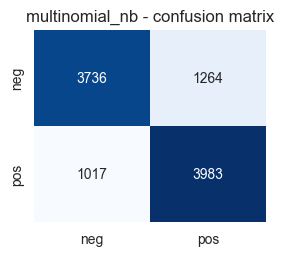

{'model': 'multinomial_nb',
 'accuracy': 0.7719,
 'precision': 0.7725651571067971,
 'recall': 0.7719,
 'f1': 0.7717607535181139}

In [ ]:
nb = MultinomialNB()
nb.fit(X_train, y_train)
evaluate('multinomial_nb', y_test, nb.predict(X_test))

## Decision Tree

              precision    recall  f1-score   support

           0       0.99      0.96      0.97      5000
           1       0.96      0.99      0.97      5000

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



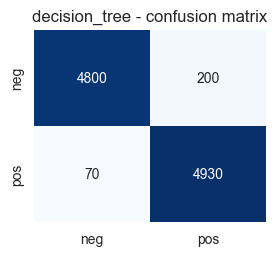

{'model': 'decision_tree',
 'accuracy': 0.973,
 'precision': 0.973319964295864,
 'recall': 0.973,
 'f1': 0.9729954362287226}

In [ ]:
dt = DecisionTreeClassifier(max_depth=20, min_samples_leaf=4,
                            random_state=SEED)
dt.fit(X_train, y_train)
evaluate('decision_tree', y_test, dt.predict(X_test))

## XGBoost

`xgboost >= 2.0` requires `early_stopping_rounds` in the constructor
(the original notebook passed it to `.fit` which is now removed).

Best iteration: 399


              precision    recall  f1-score   support

           0       1.00      0.98      0.99      5000
           1       0.98      1.00      0.99      5000

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



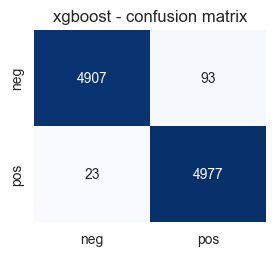

{'model': 'xgboost',
 'accuracy': 0.9884,
 'precision': 0.9884957451660524,
 'recall': 0.9884,
 'f1': 0.9883994315721469}

In [ ]:
xgb = XGBClassifier(
    n_estimators=400, learning_rate=0.1, max_depth=6,
    subsample=0.9, colsample_bytree=0.9,
    eval_metric='logloss', early_stopping_rounds=20,
    random_state=SEED, n_jobs=-1, tree_method='hist',
)
xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
print(f'Best iteration: {xgb.best_iteration}')
evaluate('xgboost', y_test, xgb.predict(X_test))

# Classification using Neural Networks

## Feed-forward NN

Epoch 1/50


125/125 - 28s - 222ms/step - accuracy: 0.8831 - loss: 0.3166 - val_accuracy: 0.9501 - val_loss: 0.1348


Epoch 2/50


125/125 - 24s - 195ms/step - accuracy: 0.9683 - loss: 0.0989 - val_accuracy: 0.9630 - val_loss: 0.0956


Epoch 3/50


...

Epoch 21/50


125/125 - 20s - 162ms/step - accuracy: 0.9986 - loss: 0.0041 - val_accuracy: 0.9768 - val_loss: 0.0990


Epoch 22/50


125/125 - 20s - 161ms/step - accuracy: 0.9990 - loss: 0.0032 - val_accuracy: 0.9783 - val_loss: 0.0965


              precision    recall  f1-score   support

           0       0.98      0.97      0.98      5000
           1       0.97      0.98      0.98      5000

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



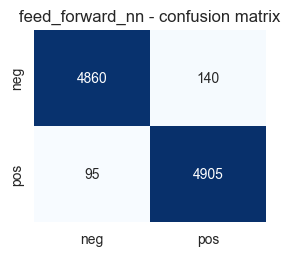

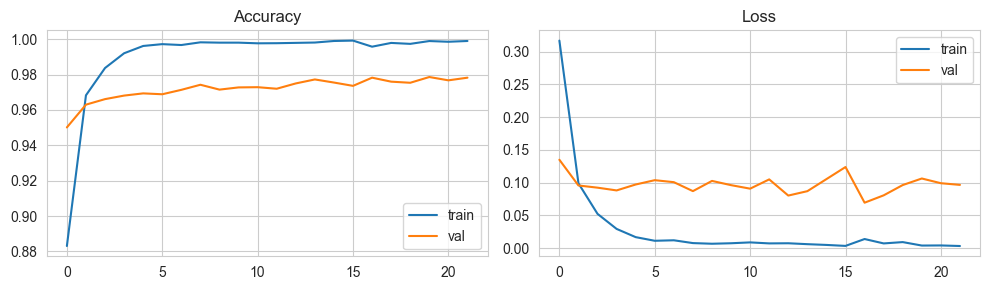

In [ ]:
# Self-bootstrap so this cell can be re-run after a kernel restart
# without re-running the imports cell above.
if 'HAS_TF' not in globals():
    try:
        import tensorflow as tf
        from tensorflow import keras
        from tensorflow.keras import layers
        HAS_TF = True
    except ImportError:
        HAS_TF = False

if HAS_TF:
    # Stream sparse TF-IDF -> dense mini-batches so we never materialise the
    # full (N x 20k) dense matrix. Keeps peak RAM to a single batch
    # (~20 MB @ batch_size=256) regardless of dataset size.
    input_dim = X_train.shape[1]
    BATCH     = 256

    def _sparse_batch_gen(X_sparse, y, batch_size=BATCH, shuffle=True):
        y_arr = np.asarray(y)
        n = X_sparse.shape[0]
        idx = np.arange(n)
        while True:
            if shuffle:
                np.random.shuffle(idx)
            for start in range(0, n, batch_size):
                sel = idx[start:start + batch_size]
                yield X_sparse[sel].toarray().astype(np.float32), y_arr[sel]

    def _steps(n, batch_size=BATCH):
        return (n + batch_size - 1) // batch_size

    def _predict_sparse(model, X_sparse, batch_size=BATCH):
        out = np.empty(X_sparse.shape[0], dtype=np.float32)
        for start in range(0, X_sparse.shape[0], batch_size):
            chunk = X_sparse[start:start + batch_size].toarray().astype(np.float32)
            out[start:start + batch_size] = model.predict(chunk, verbose=0).reshape(-1)
        return out

    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid'),
    ])
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss='binary_crossentropy', metrics=['accuracy'])
    es = keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
    history = model.fit(
        _sparse_batch_gen(X_train, y_train),
        steps_per_epoch=_steps(X_train.shape[0]),
        validation_data=_sparse_batch_gen(X_val, y_val, shuffle=False),
        validation_steps=_steps(X_val.shape[0]),
        epochs=50, callbacks=[es], verbose=2,
    )
    pred = (_predict_sparse(model, X_test) >= 0.5).astype(int)
    evaluate('feed_forward_nn', y_test, pred)

    fig, ax = plt.subplots(1, 2, figsize=(10, 3))
    ax[0].plot(history.history['accuracy'], label='train')
    ax[0].plot(history.history['val_accuracy'], label='val')
    ax[0].set_title('Accuracy'); ax[0].legend()
    ax[1].plot(history.history['loss'], label='train')
    ax[1].plot(history.history['val_loss'], label='val')
    ax[1].set_title('Loss'); ax[1].legend()
    plt.tight_layout(); plt.show()
else:
    print('TensorFlow not available - skipping.')

## Siamese NN

Twin-tower architecture sharing weights between the left and right title
TF-IDF vectors. Concatenated tower output -> sigmoid match probability.

Epoch 1/20


125/125 - 21s - 172ms/step - accuracy: 0.7781 - loss: 0.4988 - val_accuracy: 0.8133 - val_loss: 0.4321


Epoch 2/20


125/125 - 19s - 149ms/step - accuracy: 0.8399 - loss: 0.3757 - val_accuracy: 0.8109 - val_loss: 0.4448


Epoch 3/20


...

Epoch 4/20


125/125 - 18s - 146ms/step - accuracy: 0.8861 - loss: 0.2779 - val_accuracy: 0.7900 - val_loss: 0.5554


Epoch 5/20


125/125 - 18s - 141ms/step - accuracy: 0.9108 - loss: 0.2252 - val_accuracy: 0.7781 - val_loss: 0.6340


              precision    recall  f1-score   support

           0       0.86      0.74      0.80      5000
           1       0.77      0.88      0.82      5000

    accuracy                           0.81     10000
   macro avg       0.82      0.81      0.81     10000
weighted avg       0.82      0.81      0.81     10000



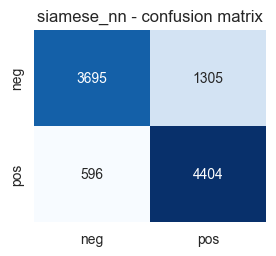

In [ ]:
# Self-bootstrap so this cell can be re-run after a kernel restart.
if 'HAS_TF' not in globals():
    try:
        import tensorflow as tf
        from tensorflow import keras
        from tensorflow.keras import layers
        HAS_TF = True
    except ImportError:
        HAS_TF = False

if HAS_TF:
    # Keep the per-side title vectors sparse, then materialise one mini-batch
    # at a time. Prevents the 2+ GiB allocation that would otherwise kill
    # machines with limited RAM.
    Xl_tr = vec.transform(pairs_train['title_left'])
    Xr_tr = vec.transform(pairs_train['title_right'])
    Xl_va = vec.transform(pairs_val['title_left'])
    Xr_va = vec.transform(pairs_val['title_right'])
    Xl_te = vec.transform(pairs_test['title_left'])
    Xr_te = vec.transform(pairs_test['title_right'])

    input_dim = Xl_tr.shape[1]
    BATCH     = 256

    def _siam_batch_gen(Xl, Xr, y, batch_size=BATCH, shuffle=True):
        y_arr = np.asarray(y)
        n = Xl.shape[0]
        idx = np.arange(n)
        while True:
            if shuffle:
                np.random.shuffle(idx)
            for start in range(0, n, batch_size):
                sel = idx[start:start + batch_size]
                yield (
                    (
                        Xl[sel].toarray().astype(np.float32),
                        Xr[sel].toarray().astype(np.float32),
                    ),
                    y_arr[sel],
                )

    def _siam_steps(n, batch_size=BATCH):
        return (n + batch_size - 1) // batch_size

    def _siam_predict(model, Xl, Xr, batch_size=BATCH):
        out = np.empty(Xl.shape[0], dtype=np.float32)
        for start in range(0, Xl.shape[0], batch_size):
            l = Xl[start:start + batch_size].toarray().astype(np.float32)
            r = Xr[start:start + batch_size].toarray().astype(np.float32)
            out[start:start + batch_size] = model.predict([l, r], verbose=0).reshape(-1)
        return out

    tower = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
    ])
    in_l = keras.Input(shape=(input_dim,))
    in_r = keras.Input(shape=(input_dim,))
    out  = layers.Dense(1, activation='sigmoid')(
                layers.Concatenate()([tower(in_l), tower(in_r)]))
    siam = keras.Model(inputs=[in_l, in_r], outputs=out)
    siam.compile(optimizer=keras.optimizers.Adam(1e-3),
                 loss='binary_crossentropy', metrics=['accuracy'])

    es = keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True)
    y_tr = pairs_train['label'].to_numpy()
    y_va = pairs_val['label'].to_numpy()
    siam.fit(
        _siam_batch_gen(Xl_tr, Xr_tr, y_tr),
        steps_per_epoch=_siam_steps(Xl_tr.shape[0]),
        validation_data=_siam_batch_gen(Xl_va, Xr_va, y_va, shuffle=False),
        validation_steps=_siam_steps(Xl_va.shape[0]),
        epochs=20, callbacks=[es], verbose=2,
    )
    pred = (_siam_predict(siam, Xl_te, Xr_te) >= 0.5).astype(int)
    evaluate('siamese_nn', pairs_test['label'].to_numpy(), pred)
else:
    print('TensorFlow not available - skipping.')

## LSTM

Concatenates the left + right titles with a `[SEP]` token and feeds the
sequence through an embedding -> LSTM -> dense head.

Epoch 1/10


125/125 - 8s - 61ms/step - accuracy: 0.7337 - loss: 0.5319 - val_accuracy: 0.8336 - val_loss: 0.4210


Epoch 2/10


125/125 - 5s - 43ms/step - accuracy: 0.8423 - loss: 0.4107 - val_accuracy: 0.8386 - val_loss: 0.4116


Epoch 3/10


...

Epoch 7/10


125/125 - 5s - 44ms/step - accuracy: 0.9128 - loss: 0.2451 - val_accuracy: 0.8615 - val_loss: 0.3773


Epoch 8/10


125/125 - 6s - 45ms/step - accuracy: 0.9213 - loss: 0.2246 - val_accuracy: 0.8665 - val_loss: 0.3579


              precision    recall  f1-score   support

           0       0.91      0.78      0.84      5000
           1       0.81      0.93      0.86      5000

    accuracy                           0.85     10000
   macro avg       0.86      0.85      0.85     10000
weighted avg       0.86      0.85      0.85     10000



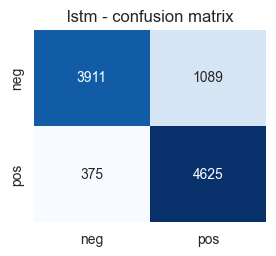

In [ ]:
# Self-bootstrap so this cell can be re-run after a kernel restart.
if 'HAS_TF' not in globals():
    try:
        import tensorflow as tf
        from tensorflow import keras
        from tensorflow.keras import layers
        HAS_TF = True
    except ImportError:
        HAS_TF = False

if HAS_TF:
    max_words = 10_000
    max_len   = 32
    tok = keras.preprocessing.text.Tokenizer(num_words=max_words, oov_token='<unk>')
    join = lambda d: (d['title_left'] + ' [SEP] ' + d['title_right']).tolist()
    tok.fit_on_texts(join(pairs_train))

    def _seq(d):
        s = tok.texts_to_sequences(join(d))
        return keras.preprocessing.sequence.pad_sequences(s, maxlen=max_len, padding='post')

    X_tr, X_va, X_te = _seq(pairs_train), _seq(pairs_val), _seq(pairs_test)

    lstm = keras.Sequential([
        layers.Input(shape=(max_len,)),
        layers.Embedding(max_words, 64),
        layers.LSTM(64),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid'),
    ])
    lstm.compile(optimizer=keras.optimizers.Adam(1e-3),
                 loss='binary_crossentropy', metrics=['accuracy'])
    es = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
    lstm.fit(X_tr, pairs_train['label'].to_numpy(),
             validation_data=(X_va, pairs_val['label'].to_numpy()),
             epochs=10, batch_size=256, callbacks=[es], verbose=2)
    pred = (lstm.predict(X_te, verbose=0).reshape(-1) >= 0.5).astype(int)
    evaluate('lstm', pairs_test['label'].to_numpy(), pred)
else:
    print('TensorFlow not available - skipping.')

## Final Comparison

,model,accuracy,precision,recall,f1
0,knn,99.63%,99.63%,99.63%,99.63%
1,xgboost,98.84%,98.85%,98.84%,98.84%
2,feed_forward_nn,97.65%,97.65%,97.65%,97.65%
3,decision_tree,97.30%,97.33%,97.30%,97.30%
4,lstm,85.36%,86.10%,85.36%,85.28%
5,random_forest,84.90%,85.28%,84.90%,84.86%
6,siamese_nn,80.99%,81.63%,80.99%,80.89%
7,linear_svm,77.84%,77.88%,77.84%,77.83%
8,multinomial_nb,77.19%,77.26%,77.19%,77.18%
9,baseline,50.00%,25.00%,50.00%,33.33%


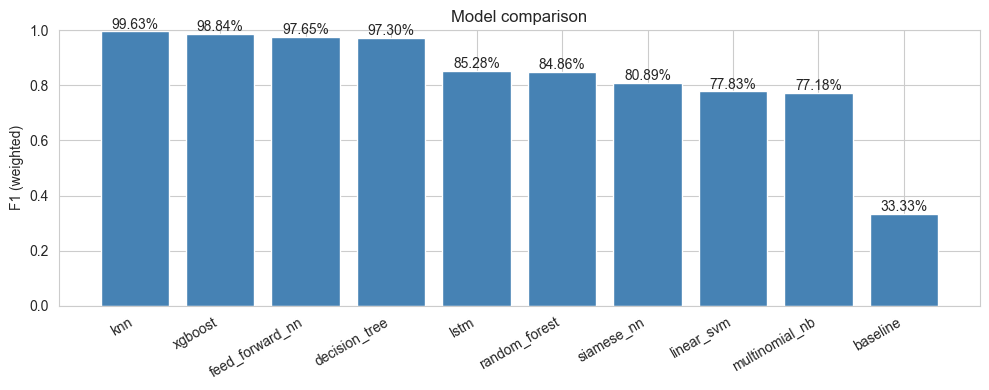

Saved results_atlas.csv


In [ ]:
results_df = pd.DataFrame(results).sort_values('f1', ascending=False).reset_index(drop=True)
display(results_df.style.format({c: '{:.2%}'
                                 for c in ('accuracy','precision','recall','f1')}))

plt.figure(figsize=(10, 4))
order = results_df['model']
plt.bar(order, results_df['f1'], color='steelblue')
plt.ylabel('F1 (weighted)'); plt.ylim(0, 1)
plt.title('Model comparison')
plt.xticks(rotation=30, ha='right')
for i, v in enumerate(results_df['f1']):
    plt.text(i, v + 0.01, f'{v:.2%}', ha='center')
plt.tight_layout(); plt.show()

results_df.to_csv('results_atlas.csv', index=False)
print('Saved results_atlas.csv')